**Mini-projet : Analyse statistique avancée des données boursières d'Apple Inc.**

1.Chargement et exploration des données

In [27]:
# Importer les bibliothèque néccessaire
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

In [28]:
# Chargement des données
data = pd.read_csv('Apple_Stock_Prices_(1981 to 2023).csv')
data.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,02/01/1981,0.154018,0.155134,0.154018,0.154018,0.119849,21660800
1,05/01/1981,0.151228,0.151228,0.150670,0.150670,0.117244,35728000
2,06/01/1981,0.144531,0.144531,0.143973,0.143973,0.112032,45158400
3,07/01/1981,0.138393,0.138393,0.137835,0.137835,0.107256,55686400
4,08/01/1981,0.135603,0.135603,0.135045,0.135045,0.105085,39827200


In [29]:
# Examinez les propriétés chronologiques des données par la fréquence, les tendances)
data['Date'] = pd.to_datetime(data['Date'], format='mixed', dayfirst=True)
data.set_index('Date', inplace=True)
data.sort_index(inplace=True)

data


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
1981-01-02,0.154018,0.155134,0.154018,0.154018,0.119849,21660800
1981-01-05,0.151228,0.151228,0.150670,0.150670,0.117244,35728000
1981-01-06,0.144531,0.144531,0.143973,0.143973,0.112032,45158400
1981-01-07,0.138393,0.138393,0.137835,0.137835,0.107256,55686400
1981-01-08,0.135603,0.135603,0.135045,0.135045,0.105085,39827200
...,...,...,...,...,...,...
2023-01-23,138.119995,143.320007,137.899994,141.110001,141.110001,81760300
2023-01-24,140.309998,143.160004,140.300003,142.529999,142.529999,66435100
2023-01-25,140.889999,142.429993,138.809998,141.860001,141.860001,65799300


2. Visualisation des données

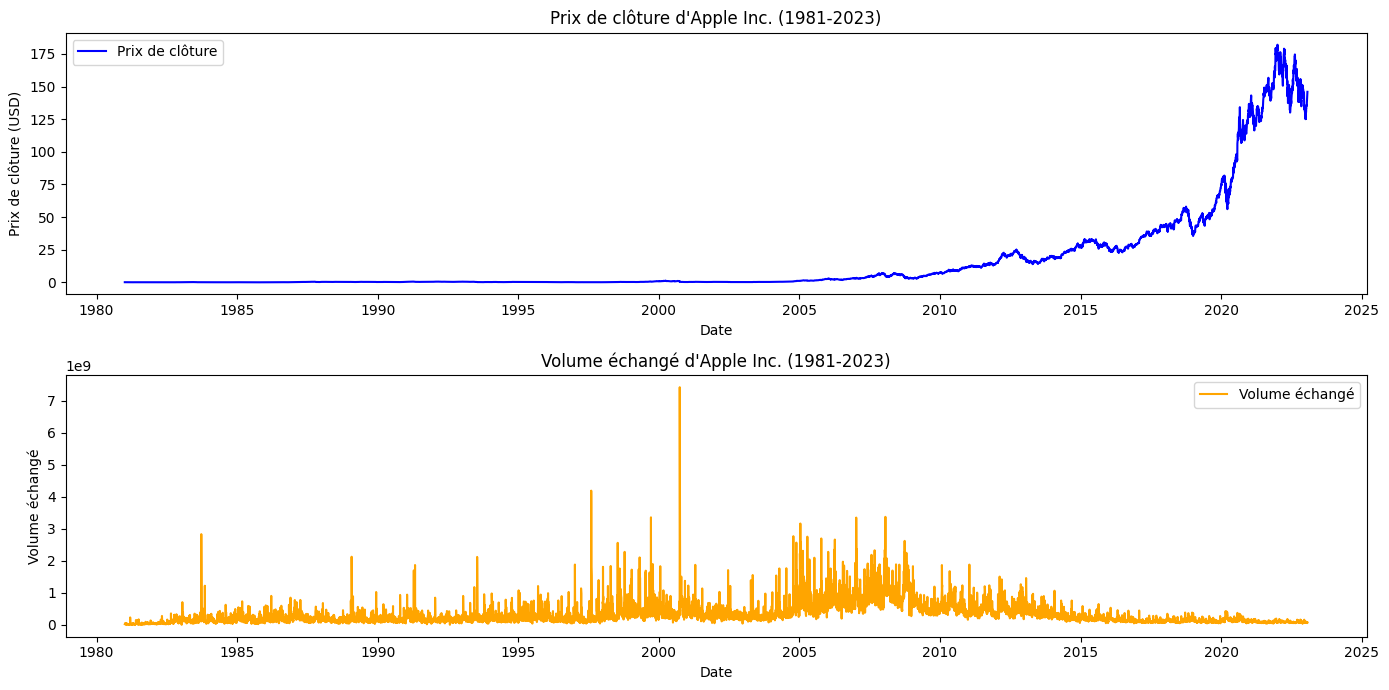

In [30]:
# Utilisez Matplotlib pour tracer les cours de clôture et les volumes échangés au fil du temps
# Créez un graphique en chandeliers pour représenter les prix hauts et bas.

plt.figure(figsize=(14, 7))
plt.subplot(2, 1, 1)
plt.plot(data.index, data['Close'], label='Prix de clôture', color='blue')
plt.title('Prix de clôture d\'Apple Inc. (1981-2023)')
plt.xlabel('Date')
plt.ylabel('Prix de clôture (USD)')
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(data.index, data['Volume'], label='Volume échangé', color='orange')
plt.title('Volume échangé d\'Apple Inc. (1981-2023)')
plt.xlabel('Date')
plt.ylabel('Volume échangé')
plt.legend()    
plt.tight_layout()
plt.show()

3. Analyse statistique

In [31]:
# Calculer les statistiques descriptives (moyenne, médiane, écart type) pour les colonnes clés
stats = data.describe()
print(stats)

               Open          High           Low         Close     Adj Close  \
count  10608.000000  10608.000000  10608.000000  10608.000000  10608.000000   
mean      16.689173     16.879955     16.500822     16.697362     16.027345   
std       35.450519     35.882848     35.031289     35.473912     35.154878   
min        0.049665      0.049665      0.049107      0.049107      0.038213   
25%        0.287946      0.296875      0.282355      0.288923      0.238909   
50%        0.488839      0.495536      0.480446      0.487701      0.404851   
75%       16.320893     16.418483     16.151249     16.269554     14.073167   
max      182.630005    182.940002    179.119995    182.009995    180.959747   

             Volume  
count  1.060800e+04  
mean   3.275098e+08  
std    3.378203e+08  
min    0.000000e+00  
25%    1.213044e+08  
50%    2.145976e+08  
75%    4.066804e+08  
max    7.421641e+09  


In [32]:
# Calculer les statistiques descriptives (moyenne, médiane, écart type) pour les colonnes clés
data_mean = np.mean(data['Close'])
data_median = np.median(data['Close'])
data_std = np.std(data['Close'])
print(f'Moyenne: {data_mean}, median: {data_median} et l\'écart type: {data_std}')

Moyenne: 16.69736201451735, median: 0.487701 et l'écart type: 35.47223956417653


In [33]:
# Analyse les cours de clôture à l'aide d'une moyenne mobile.
moyenne_mob = data['Close'].rolling(window=30).mean()
moyenne_mob

Date
1981-01-02           NaN
1981-01-05           NaN
1981-01-06           NaN
1981-01-07           NaN
1981-01-08           NaN
                 ...    
2023-01-23    134.094000
2023-01-24    134.090000
2023-01-25    134.080000
2023-01-26    134.062333
2023-01-27    134.077666
Name: Close, Length: 10608, dtype: float64

4. Tests d'hypothèses

In [ ]:
# Effectuez un test t pour comparer les cours de clôture moyens sur différentes année
